C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)


Удлинение орбиты в magnetic кольце за N = 100 оборотов
Геометрическое удлинение: 1.454198e-03 м
COSY удлинение: -1.356167e-03 м
Теоретическое удлинение: 1.778932e-03 м


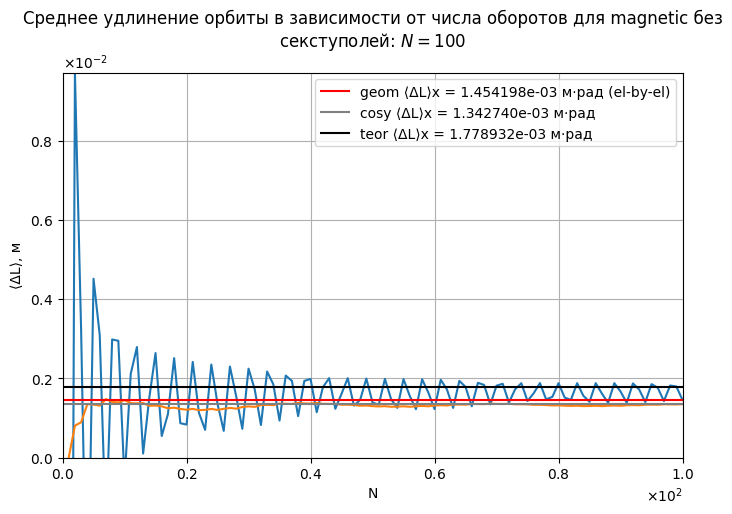

C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_18552\1703858539.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)


Удлинение орбиты в electrostatic кольце за N = 100 оборотов
Геометрическое удлинение: 3.399155e-02 м
COSY удлинение: -1.118578e-03 м
Теоретическое удлинение: 1.194637e-03 м


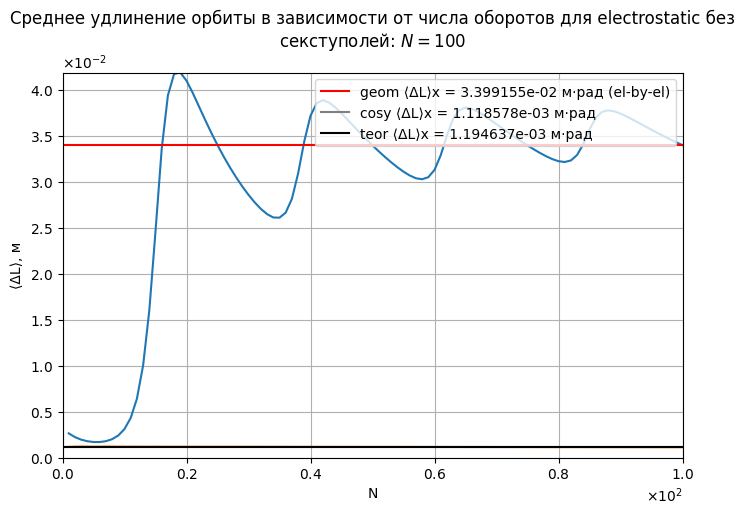

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def lenghtening(properties, lattice):
    filenames = [f"{lattice}_el-by-el.dat", f"{lattice}_optimX.dat", f"{lattice}_tracking.dat"]
    selected_ray = 1

    rho = properties[0]/(2*np.pi)   # радиус кривизны

    data = []
    for i in range(3):
        # определяем имена колонок в зависимости от файла
        if i == 0:
            names = ["iteration","EID", "ray", "X", "A", "Y", "B", "T", "D"]
        elif i == 1:
            names = ["N", "Name", "S[cm]", "L[cm]", "B[kG]", "G[kG/cm]", "S[kG/cm/cm]", "Tilt[deg]", "Tilt_out", "BendAng[deg]"]
        else:
            names = ["iteration", "ray", "X", "A", "Y", "B", "L", "D"]
    
        # читаем файл
        df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)

        # луч, для которого считается удлинение
        if "ray" in df.columns:
            df = df[df["ray"] == selected_ray]
                
        #сортировка
        if "iteration" in df.columns and "EID" in df.columns:
            df = df.sort_values(["iteration","EID"])
        elif "N" in df.columns:
            df = df.sort_values("N")
        elif "iteration" in df.columns:
            df = df.sort_values("iteration")
        data.append(df)
        
    x = data[0]["X"].values
    a = data[0]["A"].values
    b = data[0]["B"].values
    iterat = data[0]["iteration"].values
    L = np.tile(data[1]["L[cm]"].values, iterat[-1])
    delta_L = data[2]["L"].values

    print(f"Удлинение орбиты в {lattice} кольце за N = 100 оборотов")
    #Геометрическое:
    L_el = np.cumsum(((L/100) * (1 + x/rho) * np.sqrt(1 + a**2 + b**2)) - (L/100))
    avg_L_el = (L_el[-1])/iterat[-1]
    print(f"Геометрическое удлинение: {avg_L_el:.6e} м")
    #COSY:
    avg_L_COSY = delta_L[-1]/iterat[-1]
    print(f"COSY удлинение: {avg_L_COSY:.6e} м")
    #Теоретическое
    avg_L = -np.pi*(properties[1]*(properties[5]**2/properties[3]) + properties[2]*(properties[6]**2/properties[4]))
    print(f"Теоретическое удлинение: {avg_L:.6e} м")

    makeplot(L_el, delta_L, avg_L, iterat[-1], lattice)

def Lattice_properties(lattice_name):
    value = lattice_name
    match value:
        case "magnetic":
            Length = 141.014
            chrom_x = -1.879527862427126
            chrom_y = -2.637586860764062
            beta_x = 2.98732
            beta_y = 35.1547
            
            x_initial = 3e-2
            y_initial = 0
            properties = [Length, chrom_x, chrom_y, beta_x, beta_y, x_initial, y_initial]
            return(properties)

        case "magnetic_chrom":
            Length = 141.014
            chrom_x =-0.1468708320172923E-006
            chrom_y = 0.1325587937641897E-005
            beta_x = 2.98732
            beta_y = 35.1547
            
            x_initial = 3e-2
            y_initial = 0
            properties = [Length, chrom_x, chrom_y, beta_x, beta_y, x_initial, y_initial]
            return(properties)
            
        case "electrostatic":
            Length = 419.10
            chrom_x = -9.170757103137944
            chrom_y = -8.816105085121514
            beta_x = 21.7051
            beta_y = 7.75695
            
            x_initial = 3e-2
            y_initial = 0
            properties = [Length, chrom_x, chrom_y, beta_x, beta_y, x_initial, y_initial]
            return(properties)
        case _:
            return None
            
def get_data(lattice):
    properties = Lattice_properties(lattice)
    lenghtening(properties, lattice)

def makeplot(geom, cosyel, theorl, iterations, lattice):
    element_number = (len(geom)//100)
    N = np.arange(1, iterations+1) 

    geom_lengthening = (geom[(element_number*N)-1])/N
    cosy_lengthening = abs(cosyel[N-1])/N
    
    plt.figure(figsize=(8, 5))  # ширина, высота в дюймах
    plt.ylim(0, np.max(np.concatenate([geom_lengthening, cosy_lengthening])))
    plt.xlim(0, 100)   # задать диапазон по удлинению
    plt.plot(N, geom_lengthening)
    plt.plot(N, cosy_lengthening)
    plt.xlabel("N")
    plt.ylabel("⟨ΔL⟩, м")
    plt.axhline(geom[-1]/iterations, color = 'red', label=f"geom ⟨ΔL⟩x = {geom[-1]/iterations:.6e} м·рад (el-by-el)")  # горизонтальная линия
    plt.axhline(abs(cosyel[-1]/len(cosyel)), color = 'grey', label=f"cosy ⟨ΔL⟩x = {abs(cosyel[-1]/len(cosyel)):.6e} м·рад")  # горизонтальная линия
    plt.axhline(theorl, color = 'black', label=f"teor ⟨ΔL⟩x = {theorl:.6e} м·рад")  # горизонтальная линия
    plt.title(f"Среднее удлинение орбиты в зависимости от числа оборотов для {lattice} без секступолей: $N = {iterations}$", wrap=True)
    
    ax = plt.gca()
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_formatter(formatter)
    plt.legend( loc='upper right')
    plt.grid()
    plt.show()

get_data("magnetic")
#get_data("magnetic_chrom")
get_data("electrostatic")
